In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [5]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Remove the ID column
df = df.drop("CustomerID", axis=1)

# Convert Gender to numeric
df["Gender"] = LabelEncoder().fit_transform(df["Gender"])

# Scale all features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


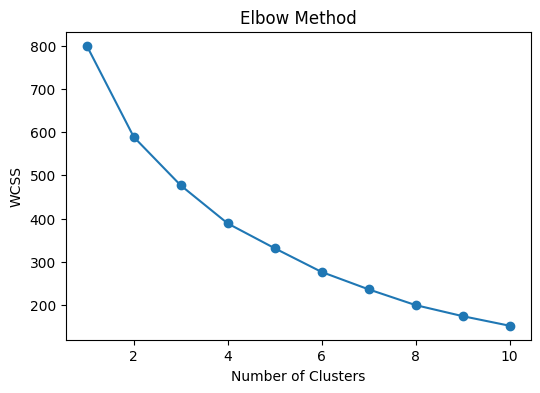

In [9]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_data)

In [11]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

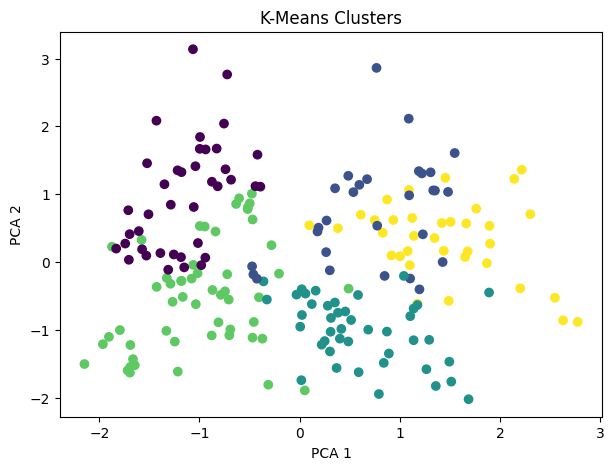

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=kmeans_labels,
    cmap='viridis'
)
plt.title("K-Means Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

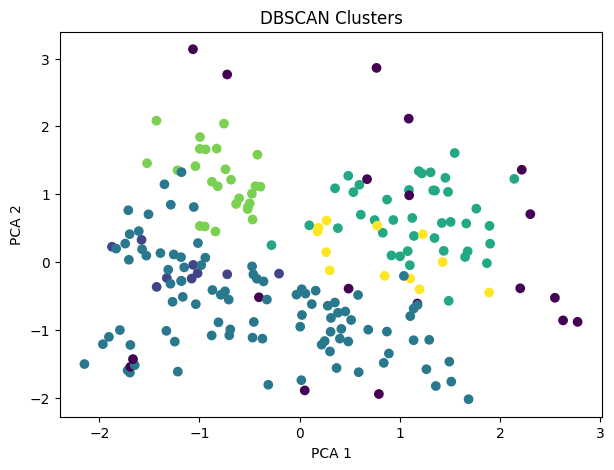

In [15]:
plt.figure(figsize=(7,5))
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=dbscan_labels,
    cmap='viridis'
)
plt.title("DBSCAN Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

##Conclusion

The Mall Customers dataset was successfully segmented using K-Means and DBSCAN clustering algorithms. The Elbow Method indicated that 5 clusters was an appropriate choice for K-Means, resulting in well-defined customer groups. DBSCAN clustered customers based on data density and identified a few isolated points as potential outliers. PCA reduced the data to two dimensions, making it easier to visualize and compare the clustering results from both algorithms.